Fig4C


PROJECT_ROOT = /home/yangqizhi/Projects/Rhythm


Using 12 models
min_models_per_cell = 4
metric_clim = {'EP': (0.034606861735297784, 0.31322183444364077), 'PLV': (0.24951876484783683, 0.8102820723552752)}


/tmp/ipykernel_2704351/1304371055.py:411: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("jet").copy()


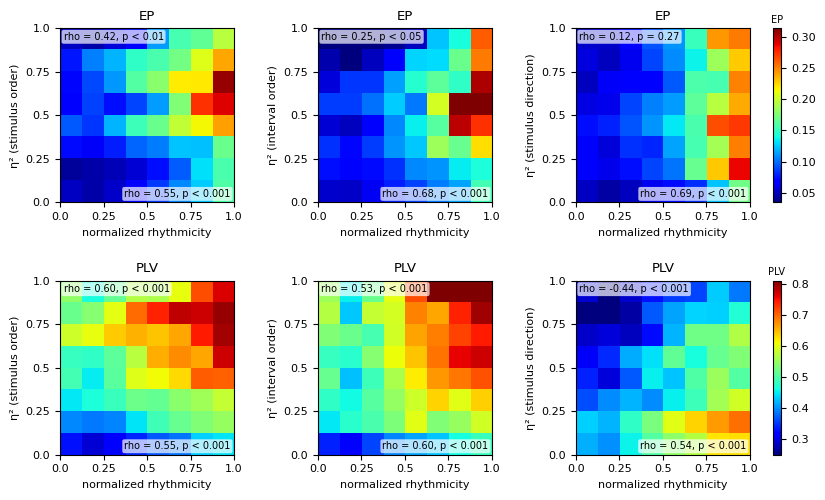

saved to: /home/yangqizhi/Projects/Rhythm/figs-submit/Fig4/Fig4C.pdf


In [1]:
# Notebook path bootstrap for moved files
import os
import sys

def find_project_root(start_dir):

    cur = os.path.abspath(start_dir)

    while True:

        if os.path.isdir(os.path.join(cur, 'figs-submit')):

            return cur

        parent = os.path.dirname(cur)

        if parent == cur:

            raise FileNotFoundError('Could not find project root containing figs-submit.')

        cur = parent

PROJECT_ROOT = find_project_root(os.getcwd())

os.chdir(PROJECT_ROOT)

FIGS_SUBMIT_DIR = os.path.join(PROJECT_ROOT, 'figs-submit')

UTILS_DIR = os.path.join(FIGS_SUBMIT_DIR, 'utils')

if FIGS_SUBMIT_DIR not in sys.path:

    sys.path.insert(0, FIGS_SUBMIT_DIR)

if UTILS_DIR not in sys.path:

    sys.path.insert(0, UTILS_DIR)

print('PROJECT_ROOT =', PROJECT_ROOT)

import math
import pickle
import warnings
import itertools
from collections import defaultdict

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

matplotlib.rcParams["svg.fonttype"] = "none"   # Keep text objects in SVG
matplotlib.rcParams["pdf.fonttype"] = 42       # Use TrueType in PDF
matplotlib.rcParams["ps.fonttype"] = 42        # Use TrueType in EPS/PS

# =========================
# user params
# =========================
model_list = [
    "all, 100-350, t3, ori",
    "all, 100-400, t8",
    "all, 100-450, t5",
    "all, 100-500, t6",

    "all, 120-350, t8",
    "all, 120-400, t10",
    "all, 120-450, t10",
    "all, 120-500, t6",

    "all, 140-350, t10",
    "all, 140-400, t7",
    "all, 140-450, t10",
    "all, 140-500, t5",
]

prepro_mode = "hilbert, no norm no baseline"
freq_ratio = 1.0

pval_thresh = 0.05
metric_display_order = ["EP", "PLV"]
char_display_order = ["stim_order", "interv_order", "stim_direction"]

char_name = {
    "stim_order": "stimulus order",
    "interv_order": "interval order",
    "stim_direction": "stimulus direction",
}

aggregate_method = "median"   # "median" or "mean"
min_models_per_cell = None    # None -> automatically set to max(2, ceil(0.3 * n_models))
n_perm_meta = 20000
rng_seed = 1234

save_path = os.path.join(PROJECT_ROOT, "figs-submit", "Fig4", "Fig4C.pdf")

# =========================
# helpers
# =========================
def format_p(p):
    if p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return "p < 0.05"
    else:
        return f"p = {p:.2f}"

def fisher_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return np.arctanh(r)

def inv_fisher_z(z):
    return np.tanh(z)

def eta2_in_bin(v, bin_idx, num_bins):
    lo = bin_idx / num_bins
    hi = (bin_idx + 1) / num_bins
    if bin_idx == num_bins - 1:
        return (v >= lo) and (v <= hi)
    return (v >= lo) and (v < hi)

def make_empty_store(num_bins, num_eta2_bins):
    out = {}
    for char in char_display_order:
        out[char] = {}
        for bin_idx in range(num_bins):
            for eta2_bin_idx in range(num_eta2_bins):
                out[char][(bin_idx, eta2_bin_idx)] = {
                    "IP": [],
                    "EP": [],
                    "PLV": [],
                }
    return out

def load_one_model_binned_cells(model_id, prepro_mode, freq_ratio, pval_thresh=0.05):
    cache_path = f"cache/Fig3x-m_{model_id}-{prepro_mode}-fr_{freq_ratio}.pkl"
    with open(cache_path, "rb") as f:
        legal_indices, _, num_bins, all_bin_stat, binned_ip_ep_plv = pickle.load(f)

    num_eta2_bins = num_bins
    store = make_empty_store(num_bins, num_eta2_bins)

    for bin_idx in range(num_bins):
        bin_stat = all_bin_stat[bin_idx]
        if bin_stat is None:
            continue

        stim_order_eta2, stim_order_pval = bin_stat[0][1], bin_stat[0][2]
        interv_order_eta2, interv_order_pval = bin_stat[1][1], bin_stat[1][2]
        stim_direction_eta2, stim_direction_pval = bin_stat[2][1], bin_stat[2][2]

        char_to_eta2 = {
            "stim_order": (stim_order_eta2, stim_order_pval),
            "interv_order": (interv_order_eta2, interv_order_pval),
            "stim_direction": (stim_direction_eta2, stim_direction_pval),
        }

        for char, (eta2_arr, pval_arr) in char_to_eta2.items():
            sig_indices = [idx for idx in legal_indices if pval_arr[idx] < pval_thresh]

            for eta2_bin_idx in range(num_eta2_bins):
                selected_indices = [
                    idx for idx in sig_indices
                    if eta2_in_bin(eta2_arr[idx], eta2_bin_idx, num_eta2_bins)
                ]

                if len(selected_indices) == 0:
                    continue

                key = (bin_idx, eta2_bin_idx)
                for metric in ["IP", "EP", "PLV"]:
                    vals = [binned_ip_ep_plv[bin_idx][metric][idx] for idx in selected_indices]
                    store[char][key][metric].extend(vals)

    return num_bins, num_eta2_bins, store

def cells_to_plot_mats(store, num_bins, num_eta2_bins):
    """
    raw mat shape: [rhythmicity_bin, eta2_bin]
    plotted mat shape after transform: [eta2_bin, rhythmicity_bin]
    x-axis -> rhythmicity (low -> high)
    y-axis -> eta2 (low -> high)
    """
    plot_mats = {}
    plot_counts = {}

    for char in char_display_order:
        for metric in metric_display_order:
            raw_mat = np.full((num_bins, num_eta2_bins), np.nan, dtype=float)
            raw_cnt = np.zeros((num_bins, num_eta2_bins), dtype=int)

            for bin_idx in range(num_bins):
                for eta2_bin_idx in range(num_eta2_bins):
                    key = (bin_idx, eta2_bin_idx)
                    vals = np.asarray(store[char][key][metric], dtype=float)
                    vals = vals[np.isfinite(vals)]

                    raw_cnt[bin_idx, eta2_bin_idx] = len(vals)
                    if len(vals) > 0:
                        raw_mat[bin_idx, eta2_bin_idx] = np.mean(vals)

            # Display direction consistent with current code
            plot_mat = np.fliplr(raw_mat.T)
            plot_cnt = np.fliplr(raw_cnt.T)

            plot_mats[(char, metric)] = plot_mat
            plot_counts[(char, metric)] = plot_cnt

    return plot_mats, plot_counts

def axis_spearman(plot_mat, axis="x"):
    valid = np.isfinite(plot_mat)
    if valid.sum() < 3:
        return np.nan

    y_idx, x_idx = np.where(valid)
    z = plot_mat[valid].astype(float)

    coord = x_idx.astype(float) if axis == "x" else y_idx.astype(float)
    rho = spearmanr(coord, z).statistic
    if rho is None:
        return np.nan
    return float(rho)

def signflip_meta_test(rho_list, n_perm=20000, rng=None):
    """
    Cross-model summary: 
    - Each model first yields one rho
    -  Fisher-z  rho  sign-flip  against 0
    """
    rho_arr = np.asarray(rho_list, dtype=float)
    rho_arr = rho_arr[np.isfinite(rho_arr)]
    n = len(rho_arr)

    if n == 0:
        return np.nan, np.nan, 0

    z = fisher_z(rho_arr)
    obs = np.mean(z)

    if n <= 15:
        all_signs = np.array(list(itertools.product([-1.0, 1.0], repeat=n)), dtype=float)
        perm_means = (all_signs * z[None, :]).mean(axis=1)
    else:
        if rng is None:
            rng = np.random.default_rng(1234)
        signs = rng.choice([-1.0, 1.0], size=(n_perm, n))
        perm_means = (signs * z[None, :]).mean(axis=1)

    p = (np.sum(np.abs(perm_means) >= abs(obs)) + 1) / (len(perm_means) + 1)
    rho_summary = inv_fisher_z(obs)
    return float(rho_summary), float(p), int(n)

def aggregate_model_stack(model_plot_mats, method="median", min_models_per_cell=3):
    """
    model_plot_mats: list of 2D mats from different models
    "Model cell "
     median,  mean 
    """
    stack = np.stack(model_plot_mats, axis=0)  # [n_model, y, x]
    support = np.sum(np.isfinite(stack), axis=0)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        if method == "median":
            agg = np.nanmedian(stack, axis=0)
        elif method == "mean":
            agg = np.nanmean(stack, axis=0)
        else:
            raise ValueError(f"Unknown aggregate method: {method}")

    agg = agg.astype(float)
    agg[support < min_models_per_cell] = np.nan
    return agg, support, stack

def compute_metric_clim_from_agg(agg_panel_mats, robust=True, q=(2, 98)):
    """
    "" metric  colorbar .
    agg_panel_mats[(char, metric)] = 2D aggregated plot mat
    """
    metric_clim = {}

    for metric in metric_display_order:
        vals = []
        for char in char_display_order:
            arr = np.asarray(agg_panel_mats[(char, metric)], dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size > 0:
                vals.append(arr)

        if len(vals) == 0:
            metric_clim[metric] = (0.0, 1.0)
            continue

        vals = np.concatenate(vals)

        if robust:
            vmin, vmax = np.percentile(vals, q)
        else:
            vmin, vmax = np.min(vals), np.max(vals)

        if np.isclose(vmin, vmax):
            pad = 1e-6 if vmax == 0 else abs(vmax) * 0.05
            vmin -= pad
            vmax += pad

        metric_clim[metric] = (float(vmin), float(vmax))

    return metric_clim

# =========================
# load all models
# =========================
if len(model_list) == 0:
    raise ValueError("Please fill model_list first.")

if min_models_per_cell is None:
    min_models_per_cell = max(2, math.ceil(0.3 * len(model_list)))

print(f"Using {len(model_list)} models")
print(f"min_models_per_cell = {min_models_per_cell}")

all_panel_model_mats = defaultdict(list)
all_panel_model_counts = defaultdict(list)
all_panel_axis_rhos = defaultdict(list)

num_bins_ref = None
num_eta2_bins_ref = None

for model_id in model_list:
    num_bins, num_eta2_bins, store = load_one_model_binned_cells(
        model_id=model_id,
        prepro_mode=prepro_mode,
        freq_ratio=freq_ratio,
        pval_thresh=pval_thresh,
    )

    if num_bins_ref is None:
        num_bins_ref = num_bins
        num_eta2_bins_ref = num_eta2_bins
    else:
        if num_bins != num_bins_ref or num_eta2_bins != num_eta2_bins_ref:
            raise ValueError("Different models have inconsistent num_bins.")

    plot_mats, plot_counts = cells_to_plot_mats(store, num_bins, num_eta2_bins)

    for char in char_display_order:
        for metric in metric_display_order:
            key = (char, metric)
            mat = plot_mats[key]

            all_panel_model_mats[key].append(mat)
            all_panel_model_counts[key].append(plot_counts[key])

            rho_x = axis_spearman(mat, axis="x")
            rho_y = axis_spearman(mat, axis="y")

            all_panel_axis_rhos[(char, metric, "x")].append(rho_x)
            all_panel_axis_rhos[(char, metric, "y")].append(rho_y)

# ========================= 
# aggregate panels + metric color limits
# =========================
agg_panel_mats = {}
agg_panel_support = {}

for char in char_display_order:
    for metric in metric_display_order:
        key = (char, metric)
        agg_mat, support, _ = aggregate_model_stack(
            all_panel_model_mats[key],
            method=aggregate_method,
            min_models_per_cell=min_models_per_cell,
        )
        agg_panel_mats[key] = agg_mat
        agg_panel_support[key] = support
        
metric_clim = compute_metric_clim_from_agg(
    agg_panel_mats,
    robust=True,     # 
    q=(1, 99),       #  (1, 99)
)
print("metric_clim =", metric_clim)

# =========================
# plot
# =========================
# font_path = "utils/Arial"
# font_files = matplotlib.font_manager.findSystemFonts(fontpaths=font_path)
# for file in font_files:
#     matplotlib.font_manager.fontManager.addfont(file)

# plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, axes = plt.subplots(
    nrows=len(metric_display_order),
    ncols=len(char_display_order),
    figsize=(9, 5.2),
    constrained_layout=False,
)

if len(metric_display_order) == 1:
    axes = np.array([axes])
if len(char_display_order) == 1:
    axes = axes[:, None]

fig.subplots_adjust(left=0.08, right=0.92, bottom=0.10, top=0.92, wspace=0.35, hspace=0.45)

cmap = plt.cm.get_cmap("jet").copy()
cmap.set_bad(color="lightgray")

meta_rng = np.random.default_rng(rng_seed)

for metric_idx, metric in enumerate(metric_display_order):
    last_im = None

    for char_idx, char in enumerate(char_display_order):
        ax = axes[metric_idx, char_idx]
        key = (char, metric)

        mat = agg_panel_mats[key]
        support = agg_panel_support[key]

        vmin, vmax = metric_clim[metric]
        masked_mat = np.ma.masked_invalid(mat)

        im = ax.imshow(
            masked_mat,
            origin="lower",
            aspect=1,
            extent=[0, 1, 0, 1],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        last_im = im

        # Model: Model rho,  meta test
        rho_x, p_x, n_x = signflip_meta_test(
            all_panel_axis_rhos[(char, metric, "x")],
            n_perm=n_perm_meta,
            rng=meta_rng,
        )
        rho_y, p_y, n_y = signflip_meta_test(
            all_panel_axis_rhos[(char, metric, "y")],
            n_perm=n_perm_meta,
            rng=meta_rng,
        )

        x_annotation_text = f"rho = {rho_x:.2f}, {format_p(p_x)}"

        y_annotation_text = f"rho = {rho_y:.2f}, {format_p(p_y)}"

        ax.text(
            0.98, 0.02,
            x_annotation_text,
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=7,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.7,
                boxstyle="round,pad=0.2",
            ),
        )

        ax.text(
            0.02, 0.98,
            y_annotation_text,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=7,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.7,
                boxstyle="round,pad=0.2",
            ),
        )

        # 
        ax.set_title(metric)
        ax.set_xlabel("normalized rhythmicity")
        ax.set_xticks(np.linspace(0, 1, 5))
        ax.set_xticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])

        ax.set_ylabel(f"η² ({char_name[char]})")
        ax.set_yticks(np.linspace(0, 1, 5))
        ax.set_yticklabels(["0.0", "0.25", "0.5", "0.75", "1.0"])

        # : Model
        #  mask ; , Comment
        # for iy in range(support.shape[0]):
        #     for ix in range(support.shape[1]):
        #         if support[iy, ix] < min_models_per_cell:
        #             continue
        #         ax.text(
        #             (ix + 0.5) / support.shape[1],
        #             (iy + 0.5) / support.shape[0],
        #             str(support[iy, ix]),
        #             ha="center", va="center", fontsize=5, color="white"
        #         )

    #  metric  colorbar 
    cbar = fig.colorbar(
        last_im,
        ax=axes[metric_idx, :],
        shrink=1,
        fraction=0.035,
        pad=0.03,
    )
    cbar.ax.set_title(metric, fontsize=7, pad=4)

os.makedirs(os.path.dirname(save_path), exist_ok=True)
fig.savefig(save_path, dpi=300)
plt.show()
plt.close(fig)

print(f"saved to: {save_path}")